# PART 1 — The Curse of Dimensionality (COD)

In gene expression datasets, we often have:
- p ≫ n
- p = ~54,000 genes
- n = maybe 100–300 samples

This creates several problems:

1. Distance Becomes Meaningless

In high dimensions:
- All points become almost equally far apart.
- Euclidean distance loses discriminative power.
- Nearest neighbors are not really “near”.

2. Data Becomes Sparse

As dimensioanlity increases:

- Volume of space increases exponentially.
- Samples occupy an extremely tiny fraction of the space.
- Models struggle to generalize.

3. Overfitting Explodes

With 54,000 features:
- The model can memorize noise.
- Many genes are irrelevant.
- Spurious correlations appear.

4. Computation Becomes Expensive
- Training time increases.
- Memory usage increases.
- Model interpretability decreases.


Solution: Dimensionality Reduction

We reduce dimensionality using:
- Feature selection (e.g., SelectKBest)
- Feature extraction (e.g., PCA)
- Nonlinear visualization (e.g., t-SNE)


**Goal:**

> Preserve biological signal while removing noise.


### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#from xgboost import XGBClassifier

### Load Datasets

In [16]:
gexp = pd.read_csv('Breast_GSE45827.csv')
gexp.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


### Standardize Data 

In [17]:
X = gexp.drop(columns=["samples", "type"])
y = gexp["type"]

In [18]:
scaler = StandardScaler()
gexp_scaled = scaler.fit_transform(X)

### Variance Filtering

In [19]:
var_filter = VarianceThreshold(threshold=0.1)
X = var_filter.fit_transform(X)

print("After variance filtering:", X.shape)

After variance filtering: (151, 35192)


### Why PCA?
	•	Captures global variance
	•	Reduces correlated features
	•	Compresses thousands of genes into dozens of components

In [20]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)

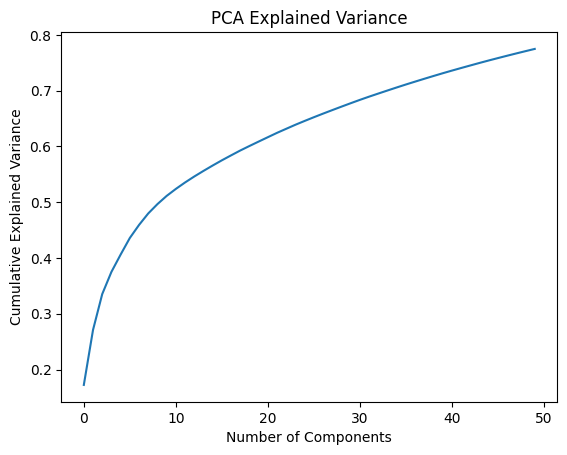

In [21]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

### Visualize PC1 v PC2

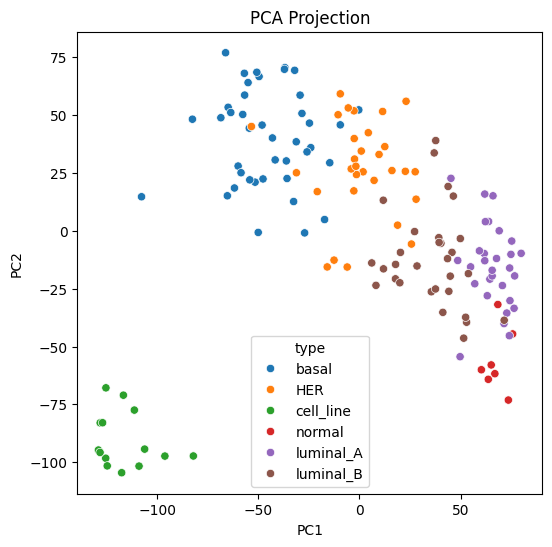

In [27]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y
})

plt.figure(figsize=(6,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="type")
plt.title("PCA Projection")
plt.show()

### Apply t-SNE on PCA

In [28]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca[:, :50])

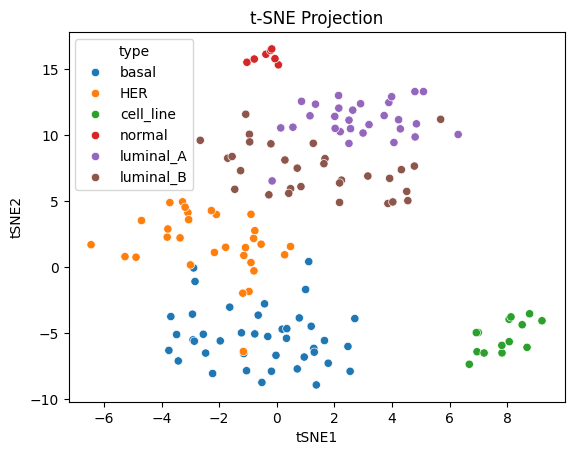

In [30]:
tsne_df = pd.DataFrame({
    "tSNE1": X_tsne[:, 0],
    "tSNE2": X_tsne[:, 1],
    "type": y
})

plt.figure()
sns.scatterplot(data=tsne_df, x="tSNE1", y="tSNE2", hue="type")
plt.title("t-SNE Projection")
plt.show()

#### Going forward,
Apart from t-SNE or UMAP clusster visualiations, PCA vectors can be used downstream for modelling your XGBoost or RF or linear model